<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/v3_EDA_Balancing_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is designed to perform Exploratory Data Analysis (EDA) on the WHSAT dataset, focusing on stratified summaries and handling class imbalance. It also includes utilities for focal loss and Bayesian class weighting preparation, aligning with the project's methodology.

# WHSAT EDA and Balancing Notebook
Implements stratified summaries, class imbalance handling, focal loss utilities, and Bayesian class weighting preparation according to the methodology.


The following cell imports all the necessary libraries for data manipulation (pandas, numpy), plotting (matplotlib), machine learning utilities (sklearn for train-test split and class weight computation), and deep learning specific modules (torch, torch.nn) which will be used for defining custom loss functions.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn

This cell is responsible for loading the dataset from a specified URL into a pandas DataFrame. It then renames several columns for better readability and consistency. Crucially, it maps the original 'Accident Level' and 'Potential Accident Level' to numerical 'severity' and 'potential_severity' values, calculates the 'near_miss_gap', handles missing severity values, and creates a 'severity_label' column by subtracting one from 'severity' to make it zero-indexed, which is often preferred for classification tasks.

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/Balanced%20Accident%20Descriptions.csv")
df = df.rename(columns={'Data':'date','Genre':'gender','Accident Level':'accident_level','Potential Accident Level':'potential_accident_level','Critical Risk':'critical_risk','Description':'description'})
severity_map={'I':1,'II':2,'III':3,'IV':4,'V':5}
df['severity']=df['accident_level'].map(severity_map)
df['potential_severity']=df['potential_accident_level'].map(severity_map)
df['near_miss_gap']=df['potential_severity']-df['severity']
df=df.dropna(subset=['severity'])
df['severity_label']=df['severity']-1
print(df[['severity','potential_severity','near_miss_gap']].head())
print(df[['severity','potential_severity','near_miss_gap']].tail())

   severity  potential_severity  near_miss_gap
0       1.0                 4.0            3.0
1       1.0                 4.0            3.0
2       1.0                 3.0            2.0
3       1.0                 1.0            0.0
4       4.0                 4.0            0.0
      severity  potential_severity  near_miss_gap
1592       2.0                 2.0            0.0
1593       2.0                 3.0            1.0
1594       2.0                 2.0            0.0
1595       2.0                 3.0            1.0
1596       2.0                 2.0            0.0


This cell performs stratified summaries to understand the distribution of accident severity levels. It shows the count of each severity level, a cross-tabulation of 'critical_risk' against 'severity' to see how critical risks relate to different severity outcomes, and the normalized proportions of each severity level, indicating the class distribution.

In [4]:
# Stratified summaries
print('Severity Distribution\t')
print(df['severity'].value_counts().sort_index())
print('\t')
print('Severity by Critical Risk\t')
print(pd.crosstab(df['critical_risk'],df['severity']).head())
print('\t')
print(pd.crosstab(df['critical_risk'],df['severity']).tail())
print('\t')
print('Severity proportions\t')
print(df['severity'].value_counts(normalize=True).sort_index())


Severity Distribution	
severity
1.0    316
2.0    300
3.0    331
4.0    330
5.0    320
Name: count, dtype: int64
	
Severity by Critical Risk	
severity                            1.0  2.0  3.0  4.0  5.0
critical_risk                                              
\nNot applicable                      0    0    0    1    0
Amputation, Crushing                  0    0    0    0   54
Asphyxiation, Drowning                0    0    0    0    8
Bees                                 10    0    0    0    0
Blocking and isolation of energies    3    0    0    0    0
	
severity                       1.0  2.0  3.0  4.0  5.0
critical_risk                                         
Traffic                          1    0    0    0    0
Transport                        0   36   48   39    0
Vehicles and Mobile Equipment    5    1    0    1    1
Venomous Animals                16    0    0    0    0
remains of choco                 2    2    0    2    1
	
Severity proportions	
severity
1.0    0.197871
2.

This cell performs a stratified train-test split on the dataset. Stratification ensures that the proportion of each severity level ('severity_label') is maintained in both the training and testing sets, which is crucial for robust model evaluation, especially with imbalanced datasets. It then prints the normalized value counts for 'severity_label' in both splits to confirm the stratification.

In [5]:
# Stratified train-test split
train_df,test_df=train_test_split(df,test_size=0.2,stratify=df['severity_label'],random_state=42)
print(train_df['severity_label'].value_counts(normalize=True).sort_index())
print(test_df['severity_label'].value_counts(normalize=True).sort_index())


severity_label
0.0    0.198121
1.0    0.187940
2.0    0.206735
3.0    0.206735
4.0    0.200470
Name: proportion, dtype: float64
severity_label
0.0    0.196875
1.0    0.187500
2.0    0.209375
3.0    0.206250
4.0    0.200000
Name: proportion, dtype: float64


This cell calculates class weights for handling imbalanced data. Using `sklearn.utils.class_weight.compute_class_weight` with the 'balanced' option, it assigns higher weights to underrepresented classes and lower weights to overrepresented classes. These weights can be used in model training to give more importance to minority classes, preventing the model from being biased towards the majority.

In [6]:
# Class weights for imbalanced data
classes=np.unique(df['severity_label'])
weights=compute_class_weight(class_weight='balanced',classes=classes,y=df['severity_label'])
class_weights=dict(zip(classes,weights))
print(class_weights)


{np.float64(0.0): np.float64(1.0107594936708861), np.float64(1.0): np.float64(1.0646666666666667), np.float64(2.0): np.float64(0.9649546827794562), np.float64(3.0): np.float64(0.9678787878787879), np.float64(4.0): np.float64(0.998125)}


This cell defines a custom `FocalLoss` class, often used for training deep learning models (like Transformer models) on imbalanced datasets. Focal Loss down-weights easy examples and focuses training on hard, misclassified examples, making it particularly effective when dealing with severe class imbalance. It initializes the loss function with the calculated class weights (`alpha`) and a gamma parameter to control the focusing effect.

In [7]:
# Focal Loss for Transformer models
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
    def forward(self,inputs,targets):
        ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
        pt=torch.exp(-ce)
        loss=((1-pt)**self.gamma)*ce
        return loss.mean()

alpha=torch.tensor(weights,dtype=torch.float32)
criterion=FocalLoss(alpha=alpha,gamma=2.0)
print('Focal loss ready for DistilBERT/BERT training.')


Focal loss ready for DistilBERT/BERT training.


This cell prepares Bayesian class weights by converting the class weights computed earlier into a format suitable for Bayesian models. These weights can be integrated into the likelihood term of Bayesian logistic or ordinal regression models, providing a principled way to account for class imbalance within a Bayesian framework.

In [8]:
# Bayesian class weighting preparation
# These weights can be incorporated into the likelihood term
# of Bayesian logistic or ordinal models.

bayesian_class_weights = {int(k):float(v) for k,v in class_weights.items()}
print(bayesian_class_weights)


{0: 1.0107594936708861, 1: 1.0646666666666667, 2: 0.9649546827794562, 3: 0.9678787878787879, 4: 0.998125}


This cell provides an example of ordinal severity summaries from the training dataset. It groups the training data by 'severity' and calculates the count of each severity level and the mean 'near_miss_gap' for each. A bar plot is then generated to visualize the count distribution of the stratified severity levels, helping to confirm the balance of the training data after the split.

          count  mean_near_miss_gap
severity                           
1.0         253            1.739130
2.0         240            0.600000
3.0         264            0.549242
4.0         264            0.318182
5.0         256            0.000000


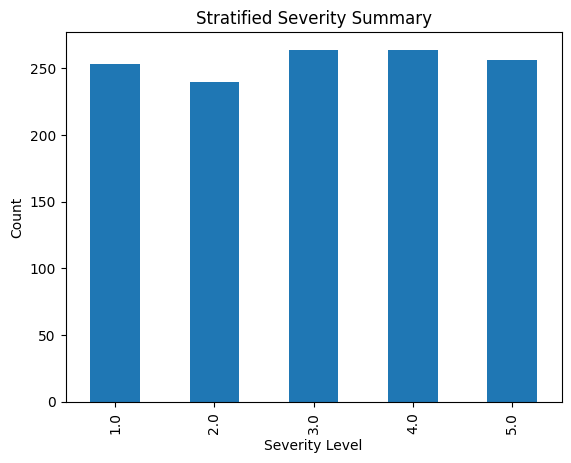

In [9]:
# Example ordinal severity summaries
summary=train_df.groupby('severity').agg(
    count=('severity','count'),
    mean_near_miss_gap=('near_miss_gap','mean')
)
print(summary)
summary['count'].plot(kind='bar')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.title('Stratified Severity Summary')
plt.show()


This cell visualizes the distribution of `potential_severity` in the dataset, providing insights into the levels of potential accidents identified before the actual incident. This helps in understanding the safety measures in place or the risk assessment capabilities.

/tmp/ipykernel_492/1423599415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='potential_severity', data=df, palette='viridis')


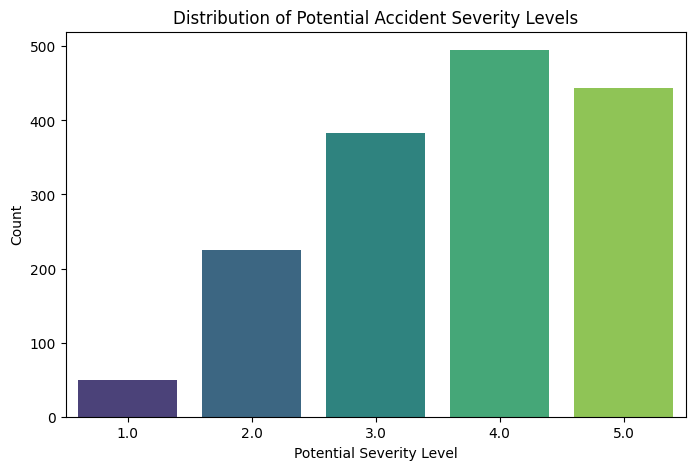

In [13]:
# Distribution of Potential Severity
plt.figure(figsize=(8, 5))
sns.countplot(x='potential_severity', data=df, palette='viridis')
plt.title('Distribution of Potential Accident Severity Levels')
plt.xlabel('Potential Severity Level')
plt.ylabel('Count')
plt.show()

This cell visualizes the distribution of the `near_miss_gap`, which represents the difference between `potential_severity` and `actual_severity`. A positive gap indicates that the potential severity was higher than the actual severity, suggesting successful intervention or luck. This chart helps understand the effectiveness of preventive measures or the impact of near-miss events.

/tmp/ipykernel_492/4051366390.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['near_miss_gap'], bins=5, kde=True, palette='magma')


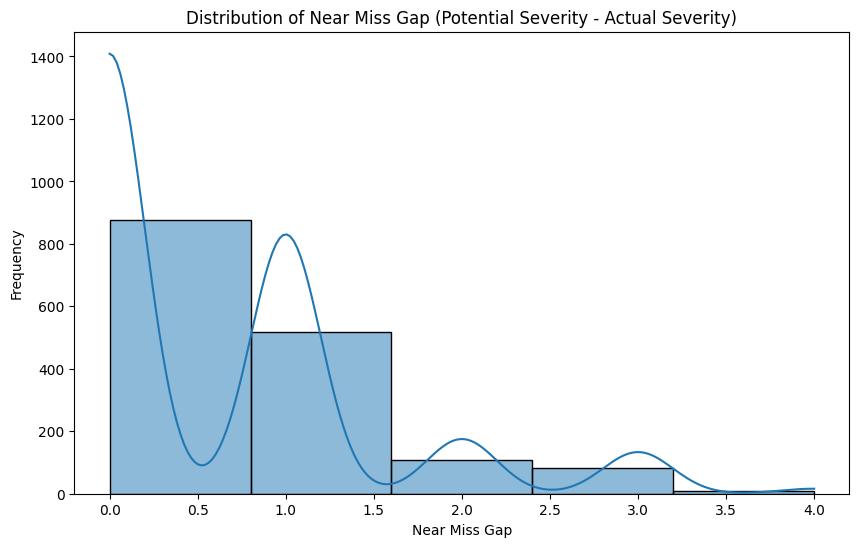

In [14]:
# Distribution of Near Miss Gap
plt.figure(figsize=(10, 6))
sns.histplot(df['near_miss_gap'], bins=5, kde=True, palette='magma')
plt.title('Distribution of Near Miss Gap (Potential Severity - Actual Severity)')
plt.xlabel('Near Miss Gap')
plt.ylabel('Frequency')
plt.show()

This cell explores the relationship between `gender` and `severity`. A grouped bar chart is used to show the count of each severity level, broken down by gender. This visualization can help identify if certain genders are disproportionately affected by accidents of specific severity levels.

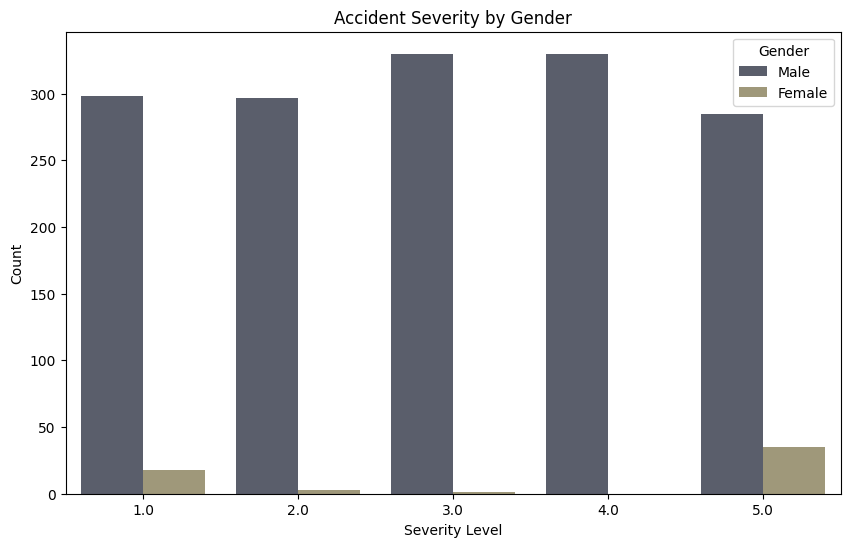

In [15]:
# Severity by Gender
plt.figure(figsize=(10, 6))
sns.countplot(x='severity', hue='gender', data=df, palette='cividis')
plt.title('Accident Severity by Gender')
plt.xlabel('Severity Level')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

This cell creates a heatmap to visualize the relationship between `critical_risk` and `severity`. Since there can be many critical risk categories, a heatmap provides a concise way to see which critical risks are associated with higher or lower accident severity levels. The values in the heatmap represent the count of occurrences for each combination.

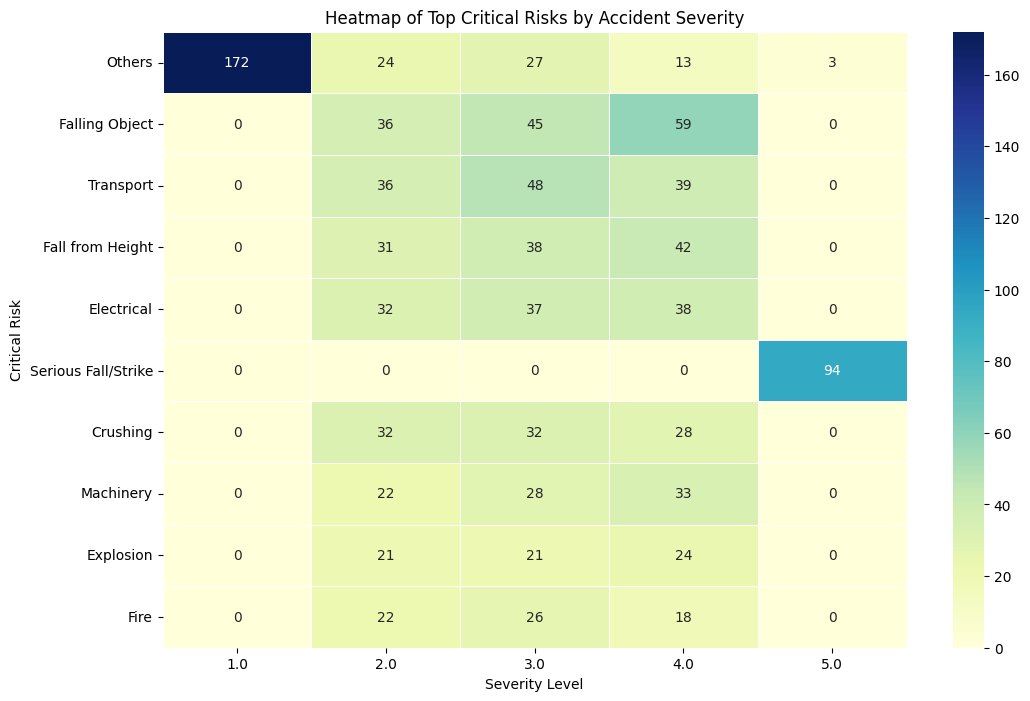

In [16]:
# Critical Risk by Severity Heatmap
crosstab_critical_risk_severity = pd.crosstab(df['critical_risk'], df['severity'])

# Filter to top N critical risks if there are too many for readability
# For example, top 10 critical risks
top_critical_risks = df['critical_risk'].value_counts().nlargest(10).index
crosstab_filtered = crosstab_critical_risk_severity.loc[top_critical_risks]

plt.figure(figsize=(12, 8))
sns.heatmap(crosstab_filtered, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap of Top Critical Risks by Accident Severity')
plt.xlabel('Severity Level')
plt.ylabel('Critical Risk')
plt.show()